In [1]:
import pandas as pd
import plotly.express as px
import random
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing


In [2]:

housing = fetch_california_housing()
housing.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])

In [3]:
print(housing.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [4]:

df = pd.DataFrame(
    housing.data,
    columns=housing.feature_names
)

df["MedHouseVal"] = housing.target

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


# Bai 1

## Phân bố giá nhà

In [5]:
px.histogram(
    df,
    x="MedHouseVal",
    nbins=50,
    title="Distribution of House Values"
)

## Histogram chồng nhóm

In [6]:
df["AgeGroup"] = pd.cut(
    df["HouseAge"],
    bins=[0,20,40,60],
    labels=["New","Middle","Old"]
)

px.histogram(
    df,
    x="MedHouseVal",
    color="AgeGroup",
    barmode="overlay"
)

## Giá nhà trung bình theo nhóm tuổi

In [7]:
age_avg = (
    df.groupby("HouseAge")["MedHouseVal"]
      .mean()
      .reset_index()
)

px.bar(
    age_avg,
    x="HouseAge",
    y="MedHouseVal"
)

## Giá nhà theo tuổi nhà

In [8]:
age_avg = (
    df.groupby("HouseAge")["MedHouseVal"]
      .mean()
      .reset_index()
)

px.line(
    age_avg,
    x="HouseAge",
    y="MedHouseVal"
)

# Bai 2

## Heatmap

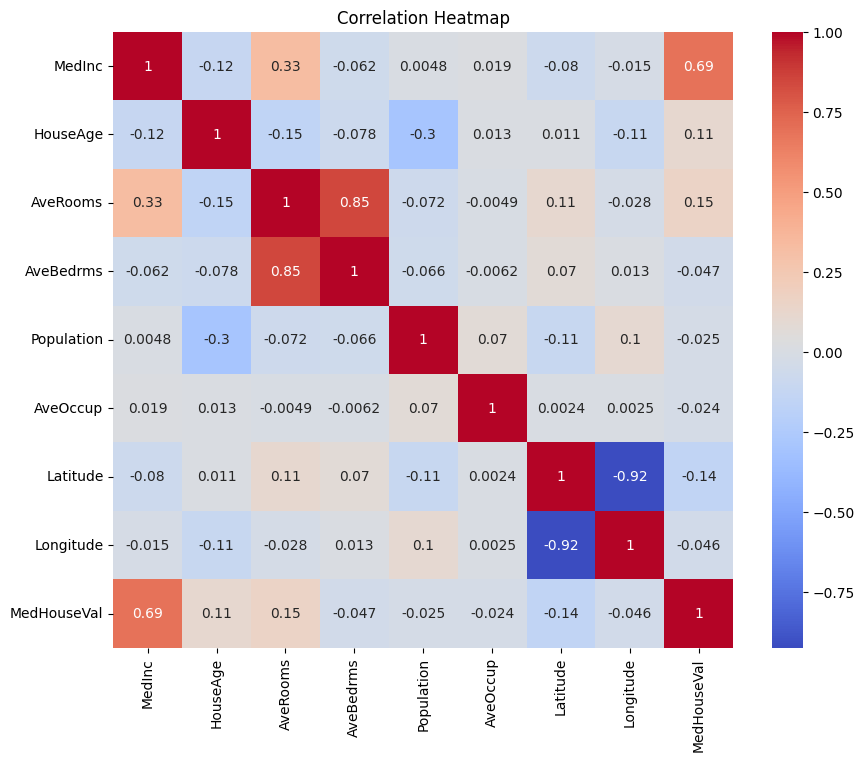

In [9]:


plt.figure(figsize=(10,8))
corr = df.select_dtypes(include="number").corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

## Violin

In [10]:
df["IncomeGroup"] = pd.qcut(
    df["MedInc"],
    q=4,
    labels=["Low","Medium","High","Very High"]
)

# 1.Nhóm Low
 ## Giá nhà tập trung chủ yếu từ khoảng 0.6 – 1.2.
 ## Median khoảng 0.8 – 0.9.
 ## Phân bố khá hẹp.

## Khu vực thu nhập thấp thường có giá nhà thấp và ít biến động.

# 2.Nhóm Medium
 ## Median tăng lên khoảng 1.5.
 ## Phân bố trải rộng hơn nhóm Low.
 ## Có một số nhà giá cao tới gần 5.0.

 ## ##Khi thu nhập tăng, giá nhà trung bình cũng tăng.

# 3.Nhóm High
 ## Median khoảng 1.9 – 2.0.
 ## Phân bố rộng hơn nữa.
 ## Xuất hiện nhiều nhà giá cao từ 2.5 – 3.5.

 ## Khu vực thu nhập cao có giá nhà cao hơn đáng kể.

# 4.Nhóm Very High
 ## Median gần 3.0.
 ## Mật độ lớn ở vùng 2.5 – 3.5.
 ## Có rất nhiều điểm tập trung gần 5.0.

 ## Đây là nhóm có giá nhà cao nhất.

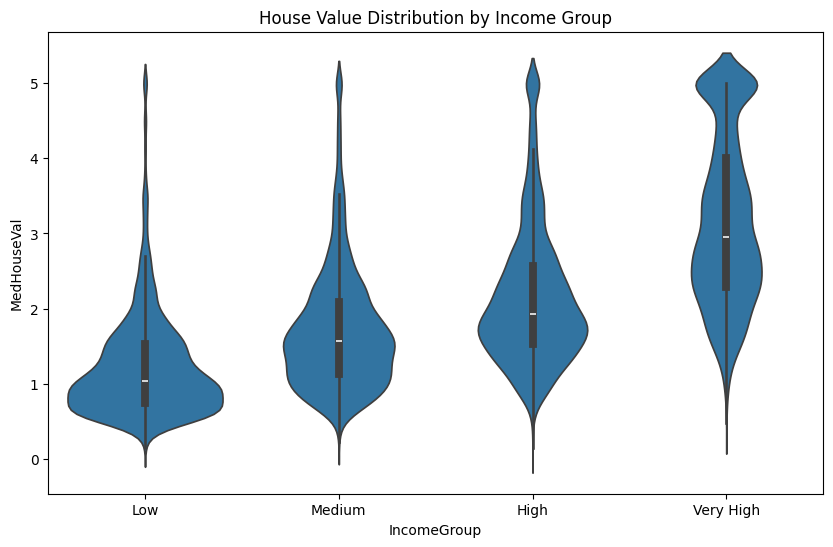

In [11]:
plt.figure(figsize=(10,6))

sns.violinplot(
    data=df,
    x="IncomeGroup",
    y="MedHouseVal"
)

plt.title("House Value Distribution by Income Group")
plt.show()

## Pairplot

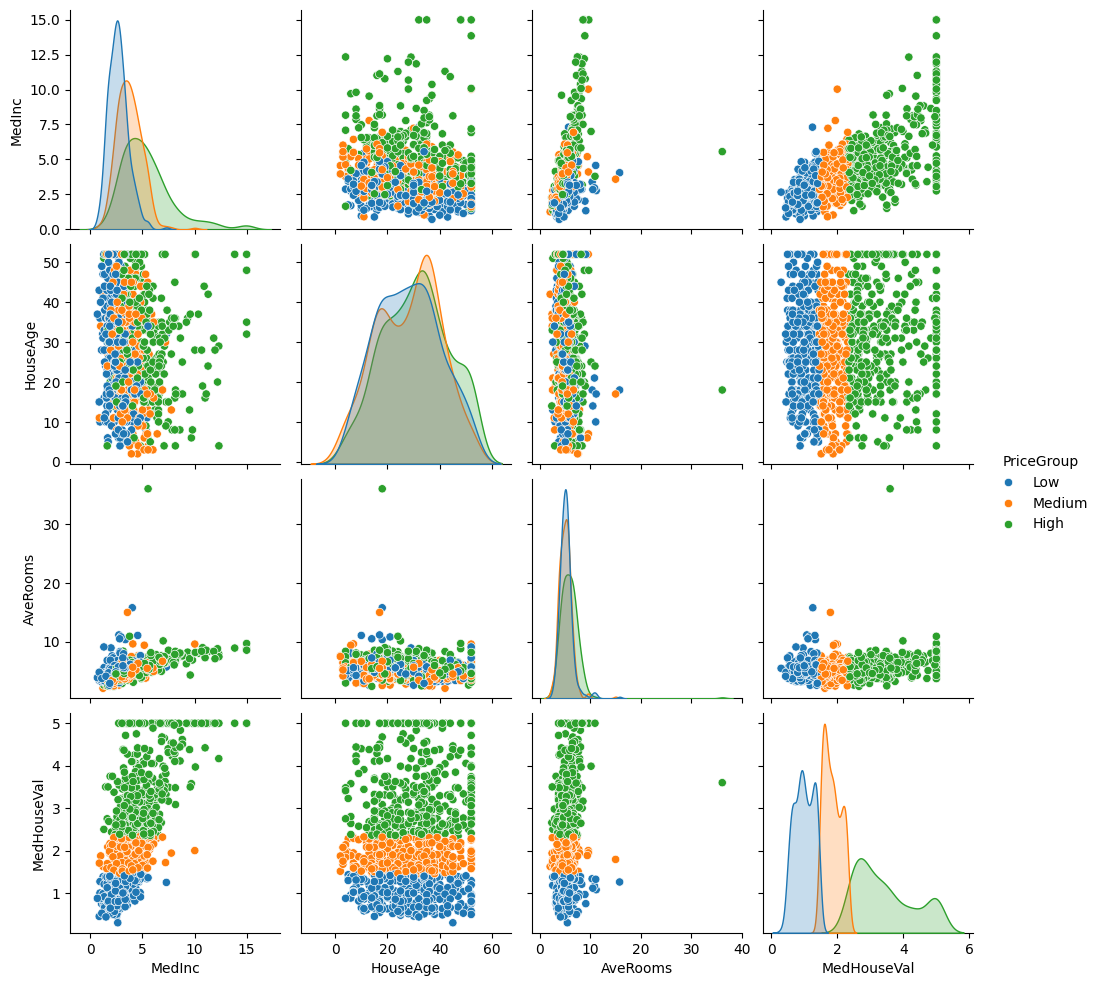

In [12]:
sample = df.sample(1000, random_state=42)
sample["PriceGroup"] = pd.qcut(
    sample["MedHouseVal"],
    q=3,
    labels=["Low","Medium","High"]
)
sns.pairplot(
    sample[
        [
            "MedInc",
            "HouseAge",
            "AveRooms",
            "MedHouseVal",
            "PriceGroup"
        ]
    ],
    hue="PriceGroup"
)

plt.show()
